In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sutun_isimleri = ["Timestamp", "CAN_ID", "DLC", 
                   "DATA0", "DATA1", "DATA2", "DATA3", 
                   "DATA4", "DATA5", "DATA6", "DATA7", "Flag"]

dos_df = pd.read_csv("data/DoS_dataset.csv", names=sutun_isimleri)
dos_df.head(10)

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Flag
0,1.478198e+09,0316,8,05,21,68,09,21,21,00,6f,R
1,1.478198e+09,018f,8,fe,5b,00,00,00,3c,00,00,R
2,1.478198e+09,0260,8,19,21,22,30,08,8e,6d,3a,R
3,1.478198e+09,02a0,8,64,00,9a,1d,97,02,bd,00,R
4,1.478198e+09,0329,8,40,bb,7f,14,11,20,00,14,R
5,1.478198e+09,0545,8,d8,00,00,8a,00,00,00,00,R
6,1.478198e+09,0002,8,00,00,00,00,00,03,0b,11,R
7,1.478198e+09,0153,8,00,21,10,ff,00,ff,00,00,R
8,1.478198e+09,02c0,8,14,00,00,00,00,00,00,00,R
9,1.478198e+09,0130,8,08,80,00,ff,31,80,0b,7f,R


In [2]:
print(dos_df.shape)
print(dos_df.dtypes)
print(dos_df["Flag"].value_counts())

(3665771, 12)
Timestamp    float64
CAN_ID           str
DLC            int64
DATA0            str
DATA1            str
DATA2            str
DATA3            str
DATA4            str
DATA5            str
DATA6            str
DATA7            str
Flag             str
dtype: object
Flag
R    3047062
T     587521
Name: count, dtype: int64


In [5]:
with open("data/DoS_dataset.csv") as f:
    for i in range(5):
        print(f.readline())

print("---")

with open("data/normal_run_data.txt") as f:
    for i in range(5):
        print(f.readline())

1478198376.389427,0316,8,05,21,68,09,21,21,00,6f,R

1478198376.389636,018f,8,fe,5b,00,00,00,3c,00,00,R

1478198376.389864,0260,8,19,21,22,30,08,8e,6d,3a,R

1478198376.390096,02a0,8,64,00,9a,1d,97,02,bd,00,R

1478198376.390333,0329,8,40,bb,7f,14,11,20,00,14,R

---
Timestamp: 1479121434.850202        ID: 0350    000    DLC: 8    05 28 84 66 6d 00 00 a2

Timestamp: 1479121434.850423        ID: 02c0    000    DLC: 8    14 00 00 00 00 00 00 00

Timestamp: 1479121434.850977        ID: 0430    000    DLC: 8    00 00 00 00 00 00 00 00

Timestamp: 1479121434.851215        ID: 04b1    000    DLC: 8    00 00 00 00 00 00 00 00

Timestamp: 1479121434.851463        ID: 01f1    000    DLC: 8    00 00 00 00 00 00 00 00



In [6]:
import re

def normal_satiri_parse_et(satir):
    eslesme = re.match(
        r"Timestamp:\s+([\d.]+)\s+ID:\s+([0-9a-fA-F]+)\s+\d+\s+DLC:\s+(\d+)\s+(.*)",
        satir
    )
    if eslesme is None:
        return None
    
    timestamp = float(eslesme.group(1))
    can_id = eslesme.group(2)
    dlc = int(eslesme.group(3))
    data_bytes = eslesme.group(4).split()
    
    return [timestamp, can_id, dlc] + data_bytes

# Test edelim:
test_satir = "Timestamp: 1479121434.850202        ID: 0350    000    DLC: 8    05 28 84 66 6d 00 00 a2"
print(normal_satiri_parse_et(test_satir))

[1479121434.850202, '0350', 8, '05', '28', '84', '66', '6d', '00', '00', 'a2']


In [7]:
satirlar = []

with open("data/normal_run_data.txt") as f:
    for satir in f:
        sonuc = normal_satiri_parse_et(satir)
        if sonuc is not None:
            satirlar.append(sonuc)

sutun_isimleri = ["Timestamp", "CAN_ID", "DLC", 
                   "DATA0", "DATA1", "DATA2", "DATA3", 
                   "DATA4", "DATA5", "DATA6", "DATA7"]

normal_df = pd.DataFrame(satirlar, columns=sutun_isimleri)
normal_df["Flag"] = "R"   # bu dosyadaki her satır normal (Regular) trafik

print(normal_df.shape)
normal_df.head()

(988871, 12)


,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Flag
0,1.479121e+09,0350,8,05,28,84,66,6d,00,00,a2,R
1,1.479121e+09,02c0,8,14,00,00,00,00,00,00,00,R
2,1.479121e+09,0430,8,00,00,00,00,00,00,00,00,R
3,1.479121e+09,04b1,8,00,00,00,00,00,00,00,00,R
4,1.479121e+09,01f1,8,00,00,00,00,00,00,00,00,R


In [8]:
sutun_isimleri_dos = ["Timestamp", "CAN_ID", "DLC", 
                       "DATA0", "DATA1", "DATA2", "DATA3", 
                       "DATA4", "DATA5", "DATA6", "DATA7", "Flag"]

dos_df = pd.read_csv("data/DoS_dataset.csv", names=sutun_isimleri_dos)

print(dos_df.shape)
dos_df.head()

(3665771, 12)


,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Flag
0,1.478198e+09,0316,8,05,21,68,09,21,21,00,6f,R
1,1.478198e+09,018f,8,fe,5b,00,00,00,3c,00,00,R
2,1.478198e+09,0260,8,19,21,22,30,08,8e,6d,3a,R
3,1.478198e+09,02a0,8,64,00,9a,1d,97,02,bd,00,R
4,1.478198e+09,0329,8,40,bb,7f,14,11,20,00,14,R


In [9]:
print("Normal veri - Flag dağılımı:")
print(normal_df["Flag"].value_counts())

print("\nDoS veri - Flag dağılımı:")
print(dos_df["Flag"].value_counts())

Normal veri - Flag dağılımı:
Flag
R    988871
Name: count, dtype: int64

DoS veri - Flag dağılımı:
Flag
R    3047062
T     587521
Name: count, dtype: int64


In [10]:
saldiri_satirlari = dos_df[dos_df["Flag"] == "T"]
normal_satirlari = dos_df[dos_df["Flag"] == "R"]

print("Saldırı mesajlarında en sık görülen CAN ID'ler:")
print(saldiri_satirlari["CAN_ID"].value_counts().head())

print("\nNormal mesajlarda en sık görülen CAN ID'ler:")
print(normal_satirlari["CAN_ID"].value_counts().head())

Saldırı mesajlarında en sık görülen CAN ID'ler:
CAN_ID
0000    587521
Name: count, dtype: int64

Normal mesajlarda en sık görülen CAN ID'ler:
CAN_ID
0130    168118
0002    167556
0131    167016
0140    167002
018f    166931
Name: count, dtype: int64


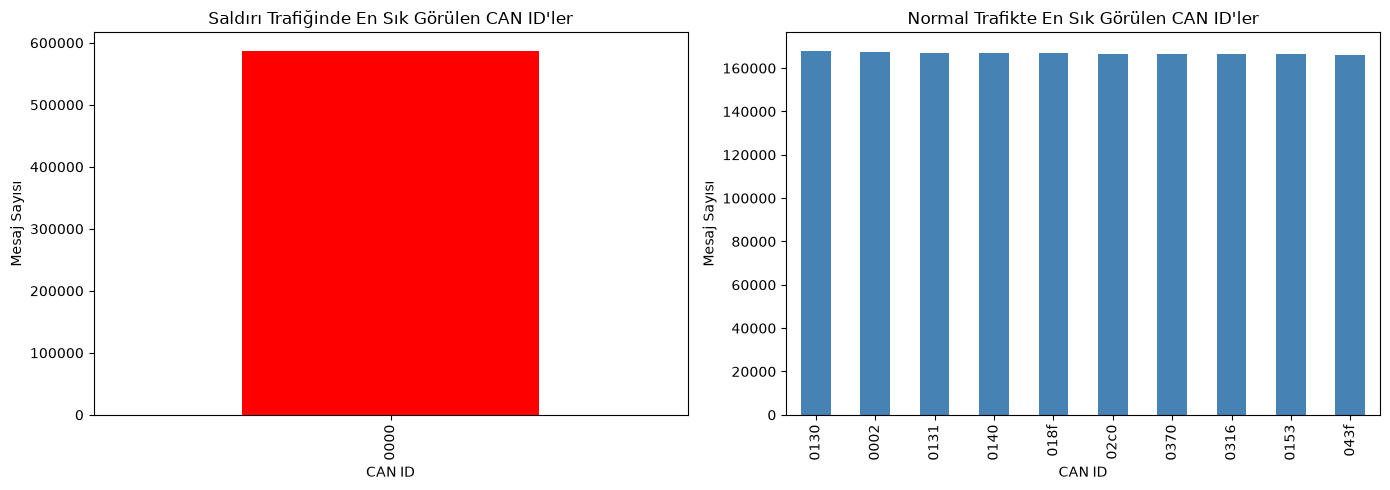

In [11]:
fig, eksenler = plt.subplots(1, 2, figsize=(14, 5))

saldiri_satirlari["CAN_ID"].value_counts().head(10).plot(kind="bar", ax=eksenler[0], color="red")
eksenler[0].set_title("Saldırı Trafiğinde En Sık Görülen CAN ID'ler")
eksenler[0].set_xlabel("CAN ID")
eksenler[0].set_ylabel("Mesaj Sayısı")

normal_satirlari["CAN_ID"].value_counts().head(10).plot(kind="bar", ax=eksenler[1], color="steelblue")
eksenler[1].set_title("Normal Trafikte En Sık Görülen CAN ID'ler")
eksenler[1].set_xlabel("CAN ID")
eksenler[1].set_ylabel("Mesaj Sayısı")

plt.tight_layout()
plt.show()

In [12]:
dos_df_sirali = dos_df.sort_values("Timestamp").reset_index(drop=True)

dos_df_sirali["zaman_farki"] = dos_df_sirali["Timestamp"].diff()

print("Saldırı mesajlarının zaman farkı istatistikleri:")
print(dos_df_sirali[dos_df_sirali["Flag"] == "T"]["zaman_farki"].describe())

print("\nNormal mesajların zaman farkı istatistikleri:")
print(dos_df_sirali[dos_df_sirali["Flag"] == "R"]["zaman_farki"].describe())

Saldırı mesajlarının zaman farkı istatistikleri:
count    587521.000000
mean          0.001366
std           0.002277
min           0.000032
25%           0.000245
50%           0.000247
75%           0.000492
max           0.067387
Name: zaman_farki, dtype: float64

Normal mesajların zaman farkı istatistikleri:
count    3.047061e+06
mean     6.575200e-04
std      1.286331e-02
min      2.384186e-05
25%      2.379417e-04
50%      2.439022e-04
75%      2.579689e-04
max      2.235827e+01
Name: zaman_farki, dtype: float64


In [13]:
dos_df_sirali["id_zaman_farki"] = dos_df_sirali.groupby("CAN_ID")["Timestamp"].diff()

print("0000 ID'li mesajların (saldırı) zaman farkı istatistikleri:")
print(dos_df_sirali[dos_df_sirali["CAN_ID"] == "0000"]["id_zaman_farki"].describe())

print("\nRastgele normal bir ID'nin (0130) zaman farkı istatistikleri:")
print(dos_df_sirali[dos_df_sirali["CAN_ID"] == "0130"]["id_zaman_farki"].describe())

0000 ID'li mesajların (saldırı) zaman farkı istatistikleri:
count    587520.000000
mean          0.003871
std           0.067848
min           0.000310
25%           0.000489
50%           0.000497
75%           0.000994
max           3.163033
Name: id_zaman_farki, dtype: float64

Rastgele normal bir ID'nin (0130) zaman farkı istatistikleri:
count    168117.000000
mean          0.016849
std           0.062456
min           0.000487
25%           0.009000
50%           0.010935
75%           0.011137
max          22.370774
Name: id_zaman_farki, dtype: float64


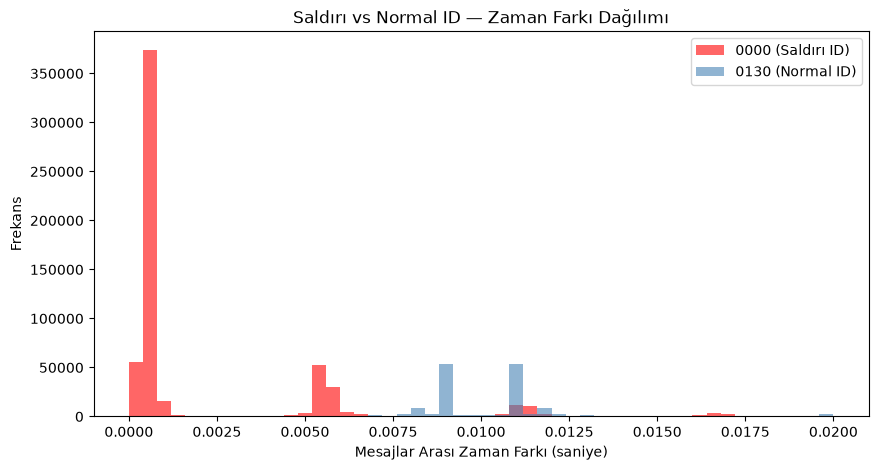

In [14]:
plt.figure(figsize=(10, 5))

saldiri_farklari = dos_df_sirali[dos_df_sirali["CAN_ID"] == "0000"]["id_zaman_farki"]
normal_farklari = dos_df_sirali[dos_df_sirali["CAN_ID"] == "0130"]["id_zaman_farki"]

plt.hist(saldiri_farklari, bins=50, range=(0, 0.02), alpha=0.6, label="0000 (Saldırı ID)", color="red")
plt.hist(normal_farklari, bins=50, range=(0, 0.02), alpha=0.6, label="0130 (Normal ID)", color="steelblue")

plt.xlabel("Mesajlar Arası Zaman Farkı (saniye)")
plt.ylabel("Frekans")
plt.title("Saldırı vs Normal ID — Zaman Farkı Dağılımı")
plt.legend()
plt.show()

In [15]:
dos_df_sirali["id_zaman_farki"] = dos_df_sirali.groupby("CAN_ID")["Timestamp"].diff()

dos_df_sirali["id_zaman_farki"] = dos_df_sirali["id_zaman_farki"].fillna(dos_df_sirali["id_zaman_farki"].median())

dos_df_sirali["can_id_numerik"] = dos_df_sirali["CAN_ID"].apply(lambda x: int(x, 16))

dos_df_sirali[["Timestamp", "CAN_ID", "can_id_numerik", "id_zaman_farki", "Flag"]].head(10)

,Timestamp,CAN_ID,can_id_numerik,id_zaman_farki,Flag
0,1.478198e+09,0316,790,0.010011,R
1,1.478198e+09,018f,399,0.010011,R
2,1.478198e+09,0260,608,0.010011,R
3,1.478198e+09,02a0,672,0.010011,R
4,1.478198e+09,0329,809,0.010011,R
5,1.478198e+09,0545,1349,0.010011,R
6,1.478198e+09,0002,2,0.010011,R
7,1.478198e+09,0153,339,0.010011,R
8,1.478198e+09,02c0,704,0.010011,R
9,1.478198e+09,0130,304,0.010011,R


In [16]:
def frekans_hesapla(grup):
    zamanlar = grup["Timestamp"].values
    sayimlar = []
    for t in zamanlar:
        sayim = ((zamanlar >= t - 1.0) & (zamanlar <= t)).sum()
        sayimlar.append(sayim)
    return pd.Series(sayimlar, index=grup.index)

ornek_boyut = 200000
kucuk_veri = dos_df_sirali.iloc[:ornek_boyut].copy()

kucuk_veri["id_frekans_1sn"] = kucuk_veri.groupby("CAN_ID", group_keys=False).apply(frekans_hesapla)

kucuk_veri[["Timestamp", "CAN_ID", "id_zaman_farki", "id_frekans_1sn", "Flag"]].tail(10)

,Timestamp,CAN_ID,id_zaman_farki,id_frekans_1sn,Flag
199990,1.478199e+09,0350,0.009901,97,R
199991,1.478199e+09,0000,0.000490,135,T
199992,1.478199e+09,0370,0.009901,96,R
199993,1.478199e+09,0000,0.000504,136,T
199994,1.478199e+09,043f,0.009903,96,R
199995,1.478199e+09,0000,0.000498,137,T
199996,1.478199e+09,0002,0.007413,97,R
199997,1.478199e+09,0000,0.000502,138,T
199998,1.478199e+09,0153,0.008404,97,R
199999,1.478199e+09,0000,0.000493,139,T


In [19]:
def hizli_frekans_hesapla(grup):
    grup = grup.copy()
    grup["zaman_dt"] = pd.to_datetime(grup["Timestamp"], unit="s")
    grup = grup.set_index("zaman_dt")
    sayim = grup["Flag"].rolling("1s").count()
    return sayim.values

In [20]:
dos_df_sirali = dos_df_sirali.sort_values(["CAN_ID", "Timestamp"]).reset_index(drop=True)

sonuclar = []
for can_id, grup in dos_df_sirali.groupby("CAN_ID"):
    sayim = hizli_frekans_hesapla(grup)
    sonuclar.append(pd.Series(sayim, index=grup.index))

dos_df_sirali["id_frekans_1sn"] = pd.concat(sonuclar).sort_index()

dos_df_sirali = dos_df_sirali.sort_values("Timestamp").reset_index(drop=True)

print(dos_df_sirali.shape)
dos_df_sirali[["Timestamp", "CAN_ID", "id_zaman_farki", "id_frekans_1sn", "Flag"]].tail(10)

(3665771, 16)


,Timestamp,CAN_ID,id_zaman_farki,id_frekans_1sn,Flag
3665761,1.478201e+09,0131,0.008993,101.0,R
3665762,1.478201e+09,0140,0.008995,101.0,R
3665763,1.478201e+09,0350,0.010485,101.0,R
3665764,1.478201e+09,04f0,0.019980,51.0,R
3665765,1.478201e+09,0316,0.009861,101.0,R
3665766,1.478201e+09,018f,0.009850,101.0,R
3665767,1.478201e+09,0260,0.009847,101.0,R
3665768,1.478201e+09,02a0,0.009845,101.0,R
3665769,1.478201e+09,0329,0.009844,101.0,R
3665770,1.478201e+09,0545,0.009847,101.0,R


In [21]:
print("id_frekans_1sn - Saldırı (T) satırları:")
print(dos_df_sirali[dos_df_sirali["Flag"] == "T"]["id_frekans_1sn"].describe())

print("\nid_frekans_1sn - Normal (R) satırları:")
print(dos_df_sirali[dos_df_sirali["Flag"] == "R"]["id_frekans_1sn"].describe())

id_frekans_1sn - Saldırı (T) satırları:
count    587521.000000
mean        462.921994
std         255.546158
min           1.000000
25%         261.000000
50%         427.000000
75%         653.000000
max        1290.000000
Name: id_frekans_1sn, dtype: float64

id_frekans_1sn - Normal (R) satırları:
count    3.047062e+06
mean     7.707758e+01
std      3.172322e+01
min      1.000000e+00
25%      5.100000e+01
50%      1.000000e+02
75%      1.010000e+02
max      1.080000e+02
Name: id_frekans_1sn, dtype: float64


In [22]:
print("Eksik değer sayısı:")
print(dos_df_sirali[["can_id_numerik", "id_zaman_farki", "id_frekans_1sn"]].isna().sum())

dos_df_sirali["etiket"] = dos_df_sirali["Flag"].map({"R": 0, "T": 1})

X = dos_df_sirali[["can_id_numerik", "id_zaman_farki", "id_frekans_1sn"]]
y = dos_df_sirali["etiket"]

print("\nX boyutu:", X.shape)
print("y dağılımı:")
print(y.value_counts())

Eksik değer sayısı:
can_id_numerik    0
id_zaman_farki    0
id_frekans_1sn    0
dtype: int64

X boyutu: (3665771, 3)
y dağılımı:
etiket
0.0    3047062
1.0     587521
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("\nEğitim doğruluğu:", model.score(X_train, y_train))
print("Test doğruluğu:", model.score(X_test, y_test))

ValueError: Input y contains NaN.

In [26]:
print(dos_df_sirali["Flag"].unique())
print(dos_df_sirali["etiket"].isna().sum())

<StringArray>
['R', nan, 'T']
Length: 3, dtype: str
31188


In [27]:
bos_satirlar = dos_df_sirali[dos_df_sirali["Flag"].isna()]
print(bos_satirlar["DLC"].value_counts())
bos_satirlar.head(10)

DLC
2    31188
Name: count, dtype: int64


,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Flag,zaman_farki,id_zaman_farki,can_id_numerik,id_frekans_1sn,etiket
36,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.002800,0.010011,1520,0.0,NaN
135,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.000139,0.051431,1520,0.0,NaN
227,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.000138,0.049683,1520,0.0,NaN
320,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.000112,0.050335,1520,0.0,NaN
412,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.000139,0.049796,1520,0.0,NaN
505,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.000162,0.050090,1520,0.0,NaN
597,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.000140,0.049616,1520,0.0,NaN
690,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.000138,0.050266,1520,0.0,NaN
782,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.000138,0.049859,1520,0.0,NaN
875,1.478198e+09,05f0,2,01,00,R,NaN,NaN,NaN,NaN,NaN,NaN,0.000138,0.050050,1520,0.0,NaN


In [28]:
kaymis_satirlar = dos_df_sirali["Flag"].isna() & (dos_df_sirali["DLC"] == 2)

dos_df_sirali.loc[kaymis_satirlar, "Flag"] = dos_df_sirali.loc[kaymis_satirlar, "DATA2"]

dos_df_sirali["etiket"] = dos_df_sirali["Flag"].map({"R": 0, "T": 1})

print("Kalan NaN sayısı:", dos_df_sirali["etiket"].isna().sum())
print(dos_df_sirali["Flag"].unique())

Kalan NaN sayısı: 0
<StringArray>
['R', 'T']
Length: 2, dtype: str


In [29]:
X = dos_df_sirali[["can_id_numerik", "id_zaman_farki", "id_frekans_1sn"]]
y = dos_df_sirali["etiket"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("\nEğitim doğruluğu:", model.score(X_train, y_train))
print("Test doğruluğu:", model.score(X_test, y_test))

Eğitim seti boyutu: (2932616, 3)
Test seti boyutu: (733155, 3)

Eğitim doğruluğu: 1.0
Test doğruluğu: 1.0


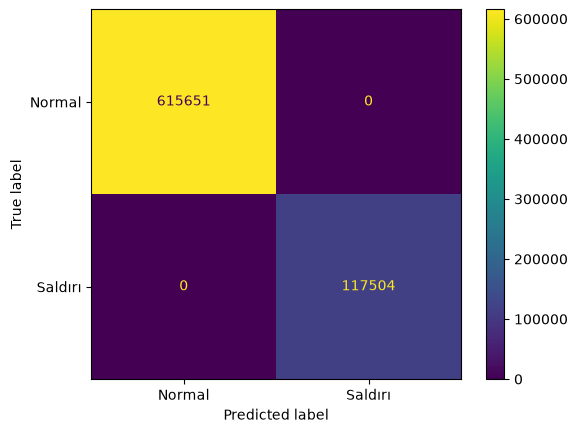

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    615651
     Saldırı       1.00      1.00      1.00    117504

    accuracy                           1.00    733155
   macro avg       1.00      1.00      1.00    733155
weighted avg       1.00      1.00      1.00    733155



In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Saldırı"])
disp.plot()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Normal", "Saldırı"]))

          ozellik      onem
0  can_id_numerik  0.387611
1  id_zaman_farki  0.330968
2  id_frekans_1sn  0.281421


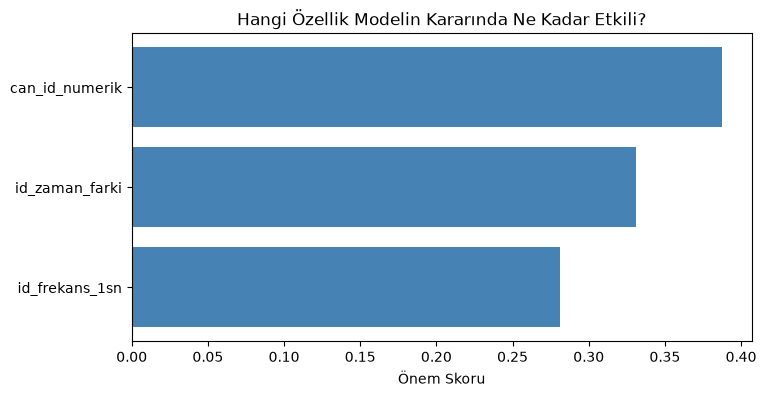

In [31]:
onem_df = pd.DataFrame({
    "ozellik": X.columns,
    "onem": model.feature_importances_
}).sort_values("onem", ascending=False)

print(onem_df)

plt.figure(figsize=(8, 4))
plt.barh(onem_df["ozellik"], onem_df["onem"], color="steelblue")
plt.xlabel("Önem Skoru")
plt.title("Hangi Özellik Modelin Kararında Ne Kadar Etkili?")
plt.gca().invert_yaxis()
plt.show()

In [32]:
def can_verisini_hazirla(dosya_yolu, sutun_isimleri):
    df = pd.read_csv(dosya_yolu, names=sutun_isimleri)
    
    # DLC=2 kayması sorununu düzelt (varsa)
    if "Flag" in df.columns and "DATA2" in df.columns:
        kaymis_satirlar = df["Flag"].isna() & (df["DLC"] == 2)
        df.loc[kaymis_satirlar, "Flag"] = df.loc[kaymis_satirlar, "DATA2"]
    
    df = df.sort_values(["CAN_ID", "Timestamp"]).reset_index(drop=True)
    
    df["id_zaman_farki"] = df.groupby("CAN_ID")["Timestamp"].diff()
    df["id_zaman_farki"] = df["id_zaman_farki"].fillna(df["id_zaman_farki"].median())
    
    df["can_id_numerik"] = df["CAN_ID"].apply(lambda x: int(x, 16))
    
    sonuclar = []
    for can_id, grup in df.groupby("CAN_ID"):
        grup = grup.copy()
        grup["zaman_dt"] = pd.to_datetime(grup["Timestamp"], unit="s")
        grup = grup.set_index("zaman_dt")
        sayim = grup["Flag"].rolling("1s").count()
        sonuclar.append(pd.Series(sayim.values, index=grup.index))
    
    df["id_frekans_1sn"] = pd.concat(sonuclar).sort_index().values
    
    df = df.sort_values("Timestamp").reset_index(drop=True)
    df["etiket"] = df["Flag"].map({"R": 0, "T": 1})
    
    df = df.dropna(subset=["etiket"])
    
    return df

In [33]:
sutun_isimleri = ["Timestamp", "CAN_ID", "DLC", 
                   "DATA0", "DATA1", "DATA2", "DATA3", 
                   "DATA4", "DATA5", "DATA6", "DATA7", "Flag"]

fuzzy_df = can_verisini_hazirla("data/Fuzzy_dataset.csv", sutun_isimleri)

print(fuzzy_df.shape)
print(fuzzy_df["Flag"].value_counts())

(3785406, 16)
Flag
R    3293559
T     491847
Name: count, dtype: int64


In [34]:
X_fuzzy = fuzzy_df[["can_id_numerik", "id_zaman_farki", "id_frekans_1sn"]]
y_fuzzy = fuzzy_df["etiket"]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fuzzy, y_fuzzy, test_size=0.2, random_state=42, stratify=y_fuzzy
)

fuzzy_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
fuzzy_model.fit(X_train_f, y_train_f)

y_pred_f = fuzzy_model.predict(X_test_f)

print(classification_report(y_test_f, y_pred_f, target_names=["Normal", "Saldırı"]))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    658712
     Saldırı       0.99      0.98      0.99     98370

    accuracy                           1.00    757082
   macro avg       0.99      0.99      0.99    757082
weighted avg       1.00      1.00      1.00    757082



In [35]:
gear_df = can_verisini_hazirla("data/gear_dataset.csv", sutun_isimleri)

X_gear = gear_df[["can_id_numerik", "id_zaman_farki", "id_frekans_1sn"]]
y_gear = gear_df["etiket"]

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gear, y_gear, test_size=0.2, random_state=42, stratify=y_gear
)

gear_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
gear_model.fit(X_train_g, y_train_g)

y_pred_g = gear_model.predict(X_test_g)

print(classification_report(y_test_g, y_pred_g, target_names=["Normal", "Saldırı"]))

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    769179
     Saldırı       0.93      0.96      0.95    119450

    accuracy                           0.99    888629
   macro avg       0.96      0.98      0.97    888629
weighted avg       0.99      0.99      0.99    888629



In [36]:
def veri_sapmasi_ekle(df):
    df = df.copy()
    df["data0_numerik"] = df["DATA0"].apply(lambda x: int(x, 16) if pd.notna(x) else 0)
    
    id_ortalama = df.groupby("CAN_ID")["data0_numerik"].transform("mean")
    id_std = df.groupby("CAN_ID")["data0_numerik"].transform("std").fillna(1)
    
    df["data0_sapma"] = (df["data0_numerik"] - id_ortalama).abs() / (id_std + 1e-6)
    
    return df

gear_df = veri_sapmasi_ekle(gear_df)
gear_df[["CAN_ID", "data0_numerik", "data0_sapma", "Flag"]].sample(10, random_state=1)

,CAN_ID,data0_numerik,data0_sapma,Flag
2375646,0140,0,0.000000,R
1480597,0140,0,0.000000,R
4197558,0370,0,0.000000,R
4087293,02c0,20,1.821475,R
3555144,0316,5,0.000000,R
4093110,0002,0,0.000000,R
2103492,0002,0,0.000000,R
4151419,0131,238,1.089537,R
2077196,0350,5,0.000000,R
2330441,0545,216,0.000000,R


In [37]:
print("Normal (R) satırlarında data0_sapma istatistikleri:")
print(gear_df[gear_df["Flag"] == "R"]["data0_sapma"].describe())

print("\nSaldırı (T) satırlarında data0_sapma istatistikleri:")
print(gear_df[gear_df["Flag"] == "T"]["data0_sapma"].describe())

Normal (R) satırlarında data0_sapma istatistikleri:
count    3.845890e+06
mean     3.722744e-01
std      6.297739e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.490003e-01
max      8.276706e+00
Name: data0_sapma, dtype: float64

Saldırı (T) satırlarında data0_sapma istatistikleri:
count    597252.000000
mean          0.483908
std           0.000000
min           0.483908
25%           0.483908
50%           0.483908
75%           0.483908
max           0.483908
Name: data0_sapma, dtype: float64


In [39]:
def guvenli_hex_cevir(x):
    try:
        return int(x, 16)
    except (ValueError, TypeError):
        return np.nan

for sutun in ["DATA0", "DATA1", "DATA2", "DATA3", "DATA4", "DATA5", "DATA6", "DATA7"]:
    gear_df[sutun + "_num"] = gear_df[sutun].apply(guvenli_hex_cevir)
    
    normal_ortalama = gear_df[gear_df["Flag"] == "R"][sutun + "_num"].mean()
    saldiri_ortalama = gear_df[gear_df["Flag"] == "T"][sutun + "_num"].mean()
    
    print(f"{sutun}: Normal ort={normal_ortalama:.2f}, Saldırı ort={saldiri_ortalama:.2f}, Fark={abs(normal_ortalama - saldiri_ortalama):.2f}")

DATA0: Normal ort=59.59, Saldırı ort=1.00, Fark=58.59
DATA1: Normal ort=43.23, Saldırı ort=69.00, Fark=25.77
DATA2: Normal ort=38.47, Saldırı ort=96.00, Fark=57.53
DATA3: Normal ort=64.14, Saldırı ort=255.00, Fark=190.86
DATA4: Normal ort=45.64, Saldırı ort=107.00, Fark=61.36
DATA5: Normal ort=61.47, Saldırı ort=0.00, Fark=61.47
DATA6: Normal ort=26.09, Saldırı ort=0.00, Fark=26.09
DATA7: Normal ort=45.36, Saldırı ort=0.00, Fark=45.36


In [47]:
def veri_sapmasi_ekle_v3(df, hedef_sutun="DATA3"):
    df = df.copy()
    
    # Önceki denemelerden kalmış olabilecek sütunları temizle
    eski_sutunlar = ["hedef_numerik", "baseline_ortalama", "baseline_std", "data3_sapma"]
    df = df.drop(columns=[s for s in eski_sutunlar if s in df.columns])
    
    df["hedef_numerik"] = df[hedef_sutun].apply(guvenli_hex_cevir)
    df["hedef_numerik"] = df["hedef_numerik"].fillna(df["hedef_numerik"].median())
    
    normal_satirlar = df[df["Flag"] == "R"]
    baseline = normal_satirlar.groupby("CAN_ID")["hedef_numerik"].agg(["mean", "std"]).reset_index()
    baseline.columns = ["CAN_ID", "baseline_ortalama", "baseline_std"]
    baseline["baseline_std"] = baseline["baseline_std"].fillna(1)
    
    df = df.merge(baseline, on="CAN_ID", how="left")
    
    df["baseline_ortalama"] = df["baseline_ortalama"].fillna(df["hedef_numerik"])
    df["baseline_std"] = df["baseline_std"].fillna(1)
    
    df["data3_sapma"] = (df["hedef_numerik"] - df["baseline_ortalama"]).abs() / (df["baseline_std"] + 1e-6)
    
    return df

In [48]:
gear_df = can_verisini_hazirla("data/gear_dataset.csv", sutun_isimleri)

In [49]:
gear_df = veri_sapmasi_ekle_v3(gear_df)
print(gear_df.columns.tolist())

['Timestamp', 'CAN_ID', 'DLC', 'DATA0', 'DATA1', 'DATA2', 'DATA3', 'DATA4', 'DATA5', 'DATA6', 'DATA7', 'Flag', 'id_zaman_farki', 'can_id_numerik', 'id_frekans_1sn', 'etiket', 'hedef_numerik', 'baseline_ortalama', 'baseline_std', 'data3_sapma']


In [50]:
print("Normal (R) satırlarında data3_sapma istatistikleri:")
print(gear_df[gear_df["Flag"] == "R"]["data3_sapma"].describe())

print("\nSaldırı (T) satırlarında data3_sapma istatistikleri:")
print(gear_df[gear_df["Flag"] == "T"]["data3_sapma"].describe())

Normal (R) satırlarında data3_sapma istatistikleri:
count    3.845890e+06
mean     1.659857e-01
std      4.086541e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.746042e+00
Name: data3_sapma, dtype: float64

Saldırı (T) satırlarında data3_sapma istatistikleri:
count    597252.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: data3_sapma, dtype: float64


In [51]:
saldiri_id = gear_df[gear_df["Flag"] == "T"]["CAN_ID"].unique()
print("Saldırıya uğrayan CAN ID(ler):", saldiri_id)

for id_deger in saldiri_id:
    normal_sayisi = gear_df[(gear_df["CAN_ID"] == id_deger) & (gear_df["Flag"] == "R")].shape[0]
    print(f"CAN ID {id_deger} — normal trafikte görülme sayısı: {normal_sayisi}")

Saldırıya uğrayan CAN ID(ler): <StringArray>
['043f']
Length: 1, dtype: str
CAN ID 043f — normal trafikte görülme sayısı: 207289


In [52]:
kontrol = gear_df[gear_df["CAN_ID"] == "043f"][["CAN_ID", "Flag", "hedef_numerik", "baseline_ortalama", "baseline_std", "data3_sapma"]]

print("Normal satırlardan örnek:")
print(kontrol[kontrol["Flag"] == "R"].head())

print("\nSaldırı satırlarından örnek:")
print(kontrol[kontrol["Flag"] == "T"].head())

Normal satırlardan örnek:
   CAN_ID Flag  hedef_numerik  baseline_ortalama  baseline_std  data3_sapma
4    043f    R          255.0              255.0           0.0          0.0
17   043f    R          255.0              255.0           0.0          0.0
40   043f    R          255.0              255.0           0.0          0.0
57   043f    R          255.0              255.0           0.0          0.0
77   043f    R          255.0              255.0           0.0          0.0

Saldırı satırlarından örnek:
     CAN_ID Flag  hedef_numerik  baseline_ortalama  baseline_std  data3_sapma
2140   043f    T          255.0              255.0           0.0          0.0
2141   043f    T          255.0              255.0           0.0          0.0
2142   043f    T          255.0              255.0           0.0          0.0
2144   043f    T          255.0              255.0           0.0          0.0
2150   043f    T          255.0              255.0           0.0          0.0


In [53]:
sadece_043f = gear_df[gear_df["CAN_ID"] == "043f"].copy()

for sutun in ["DATA0", "DATA1", "DATA2", "DATA3", "DATA4", "DATA5", "DATA6", "DATA7"]:
    sadece_043f[sutun + "_num"] = sadece_043f[sutun].apply(guvenli_hex_cevir)
    
    normal_ort = sadece_043f[sadece_043f["Flag"] == "R"][sutun + "_num"].mean()
    saldiri_ort = sadece_043f[sadece_043f["Flag"] == "T"][sutun + "_num"].mean()
    
    print(f"{sutun}: Normal ort={normal_ort:.2f}, Saldırı ort={saldiri_ort:.2f}, Fark={abs(normal_ort - saldiri_ort):.2f}")

DATA0: Normal ort=12.29, Saldırı ort=1.00, Fark=11.29
DATA1: Normal ort=64.00, Saldırı ort=69.00, Fark=5.00
DATA2: Normal ort=96.00, Saldırı ort=96.00, Fark=0.00
DATA3: Normal ort=255.00, Saldırı ort=255.00, Fark=0.00
DATA4: Normal ort=123.88, Saldırı ort=107.00, Fark=16.88
DATA5: Normal ort=126.84, Saldırı ort=0.00, Fark=126.84
DATA6: Normal ort=9.00, Saldırı ort=0.00, Fark=9.00
DATA7: Normal ort=0.00, Saldırı ort=0.00, Fark=0.00


In [54]:
gear_df = gear_df.drop(columns=["hedef_numerik", "baseline_ortalama", "baseline_std", "data3_sapma"])

gear_df = veri_sapmasi_ekle_v3(gear_df, hedef_sutun="DATA5")

print("Normal (R) satırlarında data3_sapma istatistikleri:")
print(gear_df[gear_df["Flag"] == "R"]["data3_sapma"].describe())

print("\nSaldırı (T) satırlarında data3_sapma istatistikleri:")
print(gear_df[gear_df["Flag"] == "T"]["data3_sapma"].describe())

Normal (R) satırlarında data3_sapma istatistikleri:
count    3.845890e+06
mean     4.021884e-01
std      6.017048e-01
min      0.000000e+00
25%      0.000000e+00
50%      3.221052e-02
75%      7.154905e-01
max      3.104368e+01
Name: data3_sapma, dtype: float64

Saldırı (T) satırlarında data3_sapma istatistikleri:
count    597252.000000
mean          1.570651
std           0.000000
min           1.570651
25%           1.570651
50%           1.570651
75%           1.570651
max           1.570651
Name: data3_sapma, dtype: float64


In [55]:
X_gear_v2 = gear_df[["can_id_numerik", "id_zaman_farki", "id_frekans_1sn", "data3_sapma"]]
y_gear_v2 = gear_df["etiket"]

X_train_g2, X_test_g2, y_train_g2, y_test_g2 = train_test_split(
    X_gear_v2, y_gear_v2, test_size=0.2, random_state=42, stratify=y_gear_v2
)

gear_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
gear_model_v2.fit(X_train_g2, y_train_g2)

y_pred_g2 = gear_model_v2.predict(X_test_g2)

print(classification_report(y_test_g2, y_pred_g2, target_names=["Normal", "Saldırı"]))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    769179
     Saldırı       1.00      1.00      1.00    119450

    accuracy                           1.00    888629
   macro avg       1.00      1.00      1.00    888629
weighted avg       1.00      1.00      1.00    888629



In [56]:
onem_df_gear = pd.DataFrame({
    "ozellik": X_gear_v2.columns,
    "onem": gear_model_v2.feature_importances_
}).sort_values("onem", ascending=False)

print(onem_df_gear)


          ozellik      onem
1  id_zaman_farki  0.536039
3     data3_sapma  0.373481
0  can_id_numerik  0.090128
2  id_frekans_1sn  0.000352


In [58]:
rpm_df = can_verisini_hazirla("data/RPM_dataset.csv", sutun_isimleri)

print(rpm_df.shape)
print(rpm_df["Flag"].value_counts())

(4621702, 16)
Flag
R    3966805
T     654897
Name: count, dtype: int64


In [59]:
saldiri_id = rpm_df[rpm_df["Flag"] == "T"]["CAN_ID"].unique()
print("Saldırıya uğrayan CAN ID(ler):", saldiri_id)

Saldırıya uğrayan CAN ID(ler): <StringArray>
['0316']
Length: 1, dtype: str


In [60]:
sadece_0316 = rpm_df[rpm_df["CAN_ID"] == "0316"].copy()

for sutun in ["DATA0", "DATA1", "DATA2", "DATA3", "DATA4", "DATA5", "DATA6", "DATA7"]:
    sadece_0316[sutun + "_num"] = sadece_0316[sutun].apply(guvenli_hex_cevir)
    
    normal_ort = sadece_0316[sadece_0316["Flag"] == "R"][sutun + "_num"].mean()
    saldiri_ort = sadece_0316[sadece_0316["Flag"] == "T"][sutun + "_num"].mean()
    
    print(f"{sutun}: Normal ort={normal_ort:.2f}, Saldırı ort={saldiri_ort:.2f}, Fark={abs(normal_ort - saldiri_ort):.2f}")

DATA0: Normal ort=5.00, Saldırı ort=69.00, Fark=64.00
DATA1: Normal ort=33.64, Saldırı ort=41.00, Fark=7.36
DATA2: Normal ort=95.93, Saldırı ort=36.00, Fark=59.93
DATA3: Normal ort=9.25, Saldırı ort=255.00, Fark=245.75
DATA4: Normal ort=33.64, Saldırı ort=41.00, Fark=7.36
DATA5: Normal ort=31.87, Saldırı ort=36.00, Fark=4.13
DATA6: Normal ort=0.00, Saldırı ort=0.00, Fark=0.00
DATA7: Normal ort=113.13, Saldırı ort=255.00, Fark=141.87


In [61]:
rpm_df = veri_sapmasi_ekle_v3(rpm_df, hedef_sutun="DATA7")

In [62]:
print("Normal (R) satırlarında data3_sapma istatistikleri:")
print(rpm_df[rpm_df["Flag"] == "R"]["data3_sapma"].describe())

print("\nSaldırı (T) satırlarında data3_sapma istatistikleri:")
print(rpm_df[rpm_df["Flag"] == "T"]["data3_sapma"].describe())

Normal (R) satırlarında data3_sapma istatistikleri:
count    3.966805e+06
mean     3.475085e-01
std      5.340117e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.767740e-01
max      2.489649e+00
Name: data3_sapma, dtype: float64

Saldırı (T) satırlarında data3_sapma istatistikleri:
count    6.548970e+05
mean     7.250631e+01
std      1.421087e-14
min      7.250631e+01
25%      7.250631e+01
50%      7.250631e+01
75%      7.250631e+01
max      7.250631e+01
Name: data3_sapma, dtype: float64


In [63]:
X_rpm = rpm_df[["can_id_numerik", "id_zaman_farki", "id_frekans_1sn", "data3_sapma"]]
y_rpm = rpm_df["etiket"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rpm, y_rpm, test_size=0.2, random_state=42, stratify=y_rpm
)

rpm_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rpm_model.fit(X_train_r, y_train_r)

y_pred_r = rpm_model.predict(X_test_r)

print(classification_report(y_test_r, y_pred_r, target_names=["Normal", "Saldırı"]))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    793362
     Saldırı       1.00      1.00      1.00    130979

    accuracy                           1.00    924341
   macro avg       1.00      1.00      1.00    924341
weighted avg       1.00      1.00      1.00    924341



In [64]:
def genel_sapma_ekle(df):
    df = df.copy()
    
    eski_sutunlar = ["max_data_sapma"]
    df = df.drop(columns=[s for s in eski_sutunlar if s in df.columns])
    
    normal_satirlar = df[df["Flag"] == "R"]
    sapmalar = []
    
    for byte_sutun in ["DATA0", "DATA1", "DATA2", "DATA3", "DATA4", "DATA5", "DATA6", "DATA7"]:
        gecici_sutun = byte_sutun + "_num_gecici"
        df[gecici_sutun] = df[byte_sutun].apply(guvenli_hex_cevir)
        df[gecici_sutun] = df[gecici_sutun].fillna(df[gecici_sutun].median())
        
        baseline = normal_satirlar[byte_sutun].apply(guvenli_hex_cevir)
        baseline_df = pd.DataFrame({"CAN_ID": normal_satirlar["CAN_ID"], "deger": baseline})
        baseline_ozet = baseline_df.groupby("CAN_ID")["deger"].agg(["mean", "std"]).reset_index()
        baseline_ozet.columns = ["CAN_ID", "b_ort", "b_std"]
        baseline_ozet["b_std"] = baseline_ozet["b_std"].fillna(1)
        
        df = df.merge(baseline_ozet, on="CAN_ID", how="left")
        df["b_ort"] = df["b_ort"].fillna(df[gecici_sutun])
        df["b_std"] = df["b_std"].fillna(1)
        
        sapma = (df[gecici_sutun] - df["b_ort"]).abs() / (df["b_std"] + 1e-6)
        sapmalar.append(sapma)
        
        df = df.drop(columns=[gecici_sutun, "b_ort", "b_std"])
    
    df["max_data_sapma"] = pd.concat(sapmalar, axis=1).max(axis=1)
    
    return df

In [65]:
dos_df_sirali = genel_sapma_ekle(dos_df_sirali)
fuzzy_df = genel_sapma_ekle(fuzzy_df)
gear_df = genel_sapma_ekle(gear_df)
rpm_df = genel_sapma_ekle(rpm_df)

dos_df_sirali["saldiri_turu"] = dos_df_sirali["Flag"].apply(lambda x: "DoS" if x == "T" else "Normal")
fuzzy_df["saldiri_turu"] = fuzzy_df["Flag"].apply(lambda x: "Fuzzy" if x == "T" else "Normal")
gear_df["saldiri_turu"] = gear_df["Flag"].apply(lambda x: "Gear" if x == "T" else "Normal")
rpm_df["saldiri_turu"] = rpm_df["Flag"].apply(lambda x: "RPM" if x == "T" else "Normal")

ortak_sutunlar = ["can_id_numerik", "id_zaman_farki", "id_frekans_1sn", "max_data_sapma", "saldiri_turu"]

birlesik_df = pd.concat([
    dos_df_sirali[ortak_sutunlar],
    fuzzy_df[ortak_sutunlar],
    gear_df[ortak_sutunlar],
    rpm_df[ortak_sutunlar]
], ignore_index=True)

print(birlesik_df.shape)
print(birlesik_df["saldiri_turu"].value_counts())

(16516021, 5)
saldiri_turu
Normal    14184504
RPM         654897
Gear        597252
DoS         587521
Fuzzy       491847
Name: count, dtype: int64


In [66]:
normal_satirlar_bir = birlesik_df[birlesik_df["saldiri_turu"] == "Normal"]
saldiri_satirlari_bir = birlesik_df[birlesik_df["saldiri_turu"] != "Normal"]

normal_orneklem = normal_satirlar_bir.sample(n=2000000, random_state=42)

birlesik_dengeli = pd.concat([normal_orneklem, saldiri_satirlari_bir], ignore_index=True)

birlesik_dengeli = birlesik_dengeli.sample(frac=1, random_state=42).reset_index(drop=True)

print(birlesik_dengeli.shape)
print(birlesik_dengeli["saldiri_turu"].value_counts())

(4331517, 5)
saldiri_turu
Normal    2000000
RPM        654897
Gear       597252
DoS        587521
Fuzzy      491847
Name: count, dtype: int64


In [67]:
X_birlesik = birlesik_dengeli[["can_id_numerik", "id_zaman_farki", "id_frekans_1sn", "max_data_sapma"]]
y_birlesik = birlesik_dengeli["saldiri_turu"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_birlesik, y_birlesik, test_size=0.2, random_state=42, stratify=y_birlesik
)

birlesik_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1, 
    class_weight="balanced"
)
birlesik_model.fit(X_train_b, y_train_b)

y_pred_b = birlesik_model.predict(X_test_b)

print(classification_report(y_test_b, y_pred_b))

              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00    117504
       Fuzzy       1.00      1.00      1.00     98369
        Gear       1.00      1.00      1.00    119451
      Normal       1.00      1.00      1.00    400000
         RPM       1.00      1.00      1.00    130980

    accuracy                           1.00    866304
   macro avg       1.00      1.00      1.00    866304
weighted avg       1.00      1.00      1.00    866304



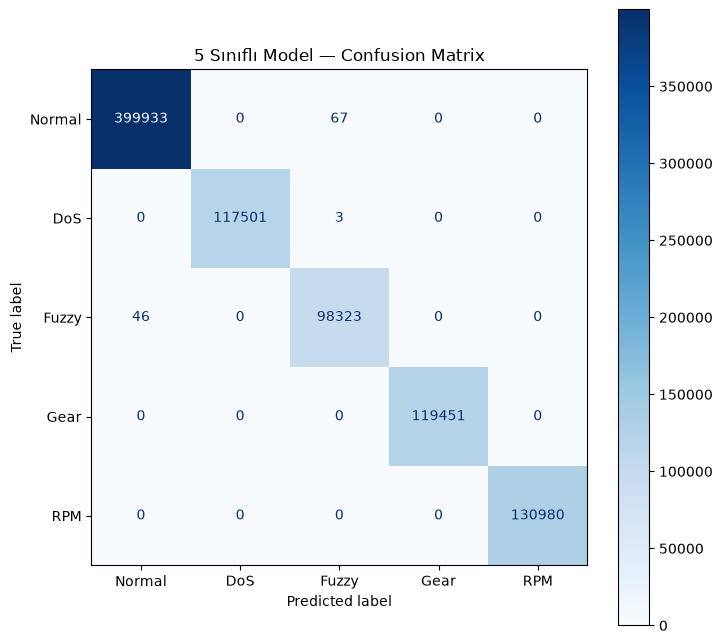

In [68]:
etiketler = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]

cm_birlesik = confusion_matrix(y_test_b, y_pred_b, labels=etiketler)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_birlesik, display_labels=etiketler)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("5 Sınıflı Model — Confusion Matrix")
plt.show()

In [69]:
cm_df = pd.DataFrame(cm_birlesik, index=etiketler, columns=etiketler)
print(cm_df)

        Normal     DoS  Fuzzy    Gear     RPM
Normal  399933       0     67       0       0
DoS          0  117501      3       0       0
Fuzzy       46       0  98323       0       0
Gear         0       0      0  119451       0
RPM          0       0      0       0  130980


In [70]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(birlesik_model, "model/canbus_model.pkl")

print("Model kaydedildi.")
print("Dosya boyutu:", os.path.getsize("model/canbus_model.pkl") / (1024*1024), "MB")

Model kaydedildi.
Dosya boyutu: 60.845643043518066 MB


In [71]:
normal_satirlar_kayit = birlesik_dengeli[birlesik_dengeli["saldiri_turu"] == "Normal"]

id_zaman_farki_medyan = normal_satirlar_kayit["id_zaman_farki"].median()

kayit_bilgisi = {
    "ozellik_sirasi": ["can_id_numerik", "id_zaman_farki", "id_frekans_1sn", "max_data_sapma"],
    "id_zaman_farki_medyan_fallback": id_zaman_farki_medyan,
    "siniflar": sorted(birlesik_dengeli["saldiri_turu"].unique().tolist())
}

joblib.dump(kayit_bilgisi, "model/model_metadata.pkl")

print(kayit_bilgisi)

{'ozellik_sirasi': ['can_id_numerik', 'id_zaman_farki', 'id_frekans_1sn', 'max_data_sapma'], 'id_zaman_farki_medyan_fallback': np.float64(0.010071039199829102), 'siniflar': ['DoS', 'Fuzzy', 'Gear', 'Normal', 'RPM']}


In [1]:
gear_ornek = gear_df[gear_df["Flag"] == "T"].iloc[0]
print("Gear saldırı örneği:")
print("CAN ID:", gear_ornek["CAN_ID"])
print("id_zaman_farki:", gear_ornek["id_zaman_farki"])
print("id_frekans_1sn:", gear_ornek["id_frekans_1sn"])
print("data3_sapma:", gear_ornek["data3_sapma"])

print()

rpm_ornek = rpm_df[rpm_df["Flag"] == "T"].iloc[0]
print("RPM saldırı örneği:")
print("CAN ID:", rpm_ornek["CAN_ID"])
print("id_zaman_farki:", rpm_ornek["id_zaman_farki"])
print("id_frekans_1sn:", rpm_ornek["id_frekans_1sn"])
print("data3_sapma:", rpm_ornek["data3_sapma"])

NameError: name 'gear_df' is not defined

In [2]:
import pandas as pd
import numpy as np

def guvenli_hex_cevir(x):
    try:
        return int(x, 16)
    except (ValueError, TypeError):
        return np.nan

def can_verisini_hazirla(dosya_yolu, sutun_isimleri):
    df = pd.read_csv(dosya_yolu, names=sutun_isimleri)
    
    if "Flag" in df.columns and "DATA2" in df.columns:
        kaymis_satirlar = df["Flag"].isna() & (df["DLC"] == 2)
        df.loc[kaymis_satirlar, "Flag"] = df.loc[kaymis_satirlar, "DATA2"]
    
    df = df.sort_values(["CAN_ID", "Timestamp"]).reset_index(drop=True)
    
    df["id_zaman_farki"] = df.groupby("CAN_ID")["Timestamp"].diff()
    df["id_zaman_farki"] = df["id_zaman_farki"].fillna(df["id_zaman_farki"].median())
    
    df["can_id_numerik"] = df["CAN_ID"].apply(lambda x: int(x, 16))
    
    sonuclar = []
    for can_id, grup in df.groupby("CAN_ID"):
        grup = grup.copy()
        grup["zaman_dt"] = pd.to_datetime(grup["Timestamp"], unit="s")
        grup = grup.set_index("zaman_dt")
        sayim = grup["Flag"].rolling("1s").count()
        sonuclar.append(pd.Series(sayim.values, index=grup.index))
    
    df["id_frekans_1sn"] = pd.concat(sonuclar).sort_index().values
    
    df = df.sort_values("Timestamp").reset_index(drop=True)
    df["etiket"] = df["Flag"].map({"R": 0, "T": 1})
    df = df.dropna(subset=["etiket"])
    
    return df

def veri_sapmasi_ekle_v3(df, hedef_sutun="DATA3"):
    df = df.copy()
    
    eski_sutunlar = ["hedef_numerik", "baseline_ortalama", "baseline_std", "data3_sapma"]
    df = df.drop(columns=[s for s in eski_sutunlar if s in df.columns])
    
    df["hedef_numerik"] = df[hedef_sutun].apply(guvenli_hex_cevir)
    df["hedef_numerik"] = df["hedef_numerik"].fillna(df["hedef_numerik"].median())
    
    normal_satirlar = df[df["Flag"] == "R"]
    baseline = normal_satirlar.groupby("CAN_ID")["hedef_numerik"].agg(["mean", "std"]).reset_index()
    baseline.columns = ["CAN_ID", "baseline_ortalama", "baseline_std"]
    baseline["baseline_std"] = baseline["baseline_std"].fillna(1)
    
    df = df.merge(baseline, on="CAN_ID", how="left")
    
    df["baseline_ortalama"] = df["baseline_ortalama"].fillna(df["hedef_numerik"])
    df["baseline_std"] = df["baseline_std"].fillna(1)
    
    df["data3_sapma"] = (df["hedef_numerik"] - df["baseline_ortalama"]).abs() / (df["baseline_std"] + 1e-6)
    
    return df

sutun_isimleri = ["Timestamp", "CAN_ID", "DLC", 
                   "DATA0", "DATA1", "DATA2", "DATA3", 
                   "DATA4", "DATA5", "DATA6", "DATA7", "Flag"]

gear_df = can_verisini_hazirla("data/gear_dataset.csv", sutun_isimleri)
gear_df = veri_sapmasi_ekle_v3(gear_df, hedef_sutun="DATA5")

rpm_df = can_verisini_hazirla("data/RPM_dataset.csv", sutun_isimleri)
rpm_df = veri_sapmasi_ekle_v3(rpm_df, hedef_sutun="DATA3")

print("Yükleme tamamlandı.")

Yükleme tamamlandı.


In [3]:
gear_ornek = gear_df[gear_df["Flag"] == "T"].iloc[0]
print("Gear saldırı örneği:")
print("CAN ID:", gear_ornek["CAN_ID"])
print("id_zaman_farki:", gear_ornek["id_zaman_farki"])
print("id_frekans_1sn:", gear_ornek["id_frekans_1sn"])
print("data3_sapma:", gear_ornek["data3_sapma"])

print()

rpm_ornek = rpm_df[rpm_df["Flag"] == "T"].iloc[0]
print("RPM saldırı örneği:")
print("CAN ID:", rpm_ornek["CAN_ID"])
print("id_zaman_farki:", rpm_ornek["id_zaman_farki"])
print("id_frekans_1sn:", rpm_ornek["id_frekans_1sn"])
print("data3_sapma:", rpm_ornek["data3_sapma"])


Gear saldırı örneği:
CAN ID: 043f
id_zaman_farki: 0.05158591270446777
id_frekans_1sn: 786.0
data3_sapma: 1.5706510589964815

RPM saldırı örneği:
CAN ID: 0316
id_zaman_farki: 0.0015261173248291016
id_frekans_1sn: 101.0
data3_sapma: 568.7775404099749


In [4]:
import joblib
model = joblib.load("model/canbus_model.pkl")
print(model.feature_names_in_ if hasattr(model, "feature_names_in_") else "İsim bilgisi yok")
print(model.n_features_in_)

['can_id_numerik' 'id_zaman_farki' 'id_frekans_1sn' 'max_data_sapma']
4


In [6]:
def genel_sapma_ekle(df):
    df = df.copy()
    
    eski_sutunlar = ["max_data_sapma"]
    df = df.drop(columns=[s for s in eski_sutunlar if s in df.columns])
    
    normal_satirlar = df[df["Flag"] == "R"]
    sapmalar = []
    
    for byte_sutun in ["DATA0", "DATA1", "DATA2", "DATA3", "DATA4", "DATA5", "DATA6", "DATA7"]:
        gecici_sutun = byte_sutun + "_num_gecici"
        df[gecici_sutun] = df[byte_sutun].apply(guvenli_hex_cevir)
        df[gecici_sutun] = df[gecici_sutun].fillna(df[gecici_sutun].median())
        
        baseline = normal_satirlar[byte_sutun].apply(guvenli_hex_cevir)
        baseline_df = pd.DataFrame({"CAN_ID": normal_satirlar["CAN_ID"], "deger": baseline})
        baseline_ozet = baseline_df.groupby("CAN_ID")["deger"].agg(["mean", "std"]).reset_index()
        baseline_ozet.columns = ["CAN_ID", "b_ort", "b_std"]
        baseline_ozet["b_std"] = baseline_ozet["b_std"].fillna(1).clip(lower=1)
        
        df = df.merge(baseline_ozet, on="CAN_ID", how="left")
        df["b_ort"] = df["b_ort"].fillna(df[gecici_sutun])
        df["b_std"] = df["b_std"].fillna(1)
        
        sapma = (df[gecici_sutun] - df["b_ort"]).abs() / (df["b_std"] + 1e-6)
        sapmalar.append(sapma)
        
        df = df.drop(columns=[gecici_sutun, "b_ort", "b_std"])
    
    df["max_data_sapma"] = pd.concat(sapmalar, axis=1).max(axis=1)
    
    return df

rpm_df = genel_sapma_ekle(rpm_df)
gear_df = genel_sapma_ekle(gear_df)

rpm_ornek = rpm_df[rpm_df["Flag"] == "T"].iloc[0]
print("RPM saldırı örneği (doğru özellikle):")
print("CAN ID:", rpm_ornek["CAN_ID"])
print("id_zaman_farki:", rpm_ornek["id_zaman_farki"])
print("id_frekans_1sn:", rpm_ornek["id_frekans_1sn"])
print("max_data_sapma:", rpm_ornek["max_data_sapma"])

print()

gear_ornek = gear_df[gear_df["Flag"] == "T"].iloc[0]
print("Gear saldırı örneği (doğru özellikle):")
print("CAN ID:", gear_ornek["CAN_ID"])
print("id_zaman_farki:", gear_ornek["id_zaman_farki"])
print("id_frekans_1sn:", gear_ornek["id_frekans_1sn"])
print("max_data_sapma:", gear_ornek["max_data_sapma"])

RPM saldırı örneği (doğru özellikle):
CAN ID: 0316
id_zaman_farki: 0.0015261173248291016
id_frekans_1sn: 101.0
max_data_sapma: 245.75138367348714

Gear saldırı örneği (doğru özellikle):
CAN ID: 043f
id_zaman_farki: 0.05158591270446777
id_frekans_1sn: 786.0
max_data_sapma: 10.01660114150945


In [7]:
dos_df_sirali = can_verisini_hazirla("data/DoS_dataset.csv", sutun_isimleri)
fuzzy_df = can_verisini_hazirla("data/Fuzzy_dataset.csv", sutun_isimleri)
gear_df = can_verisini_hazirla("data/gear_dataset.csv", sutun_isimleri)
rpm_df = can_verisini_hazirla("data/RPM_dataset.csv", sutun_isimleri)

dos_df_sirali = genel_sapma_ekle(dos_df_sirali)
fuzzy_df = genel_sapma_ekle(fuzzy_df)
gear_df = genel_sapma_ekle(gear_df)
rpm_df = genel_sapma_ekle(rpm_df)

dos_df_sirali["saldiri_turu"] = dos_df_sirali["Flag"].apply(lambda x: "DoS" if x == "T" else "Normal")
fuzzy_df["saldiri_turu"] = fuzzy_df["Flag"].apply(lambda x: "Fuzzy" if x == "T" else "Normal")
gear_df["saldiri_turu"] = gear_df["Flag"].apply(lambda x: "Gear" if x == "T" else "Normal")
rpm_df["saldiri_turu"] = rpm_df["Flag"].apply(lambda x: "RPM" if x == "T" else "Normal")

ortak_sutunlar = ["can_id_numerik", "id_zaman_farki", "id_frekans_1sn", "max_data_sapma", "saldiri_turu"]

birlesik_df = pd.concat([
    dos_df_sirali[ortak_sutunlar],
    fuzzy_df[ortak_sutunlar],
    gear_df[ortak_sutunlar],
    rpm_df[ortak_sutunlar]
], ignore_index=True)

print(birlesik_df.shape)
print(birlesik_df["saldiri_turu"].value_counts())

(16516021, 5)
saldiri_turu
Normal    14184504
RPM         654897
Gear        597252
DoS         587521
Fuzzy       491847
Name: count, dtype: int64


In [8]:
normal_satirlar_bir = birlesik_df[birlesik_df["saldiri_turu"] == "Normal"]
saldiri_satirlari_bir = birlesik_df[birlesik_df["saldiri_turu"] != "Normal"]

normal_orneklem = normal_satirlar_bir.sample(n=2000000, random_state=42)

birlesik_dengeli = pd.concat([normal_orneklem, saldiri_satirlari_bir], ignore_index=True)
birlesik_dengeli = birlesik_dengeli.sample(frac=1, random_state=42).reset_index(drop=True)

print(birlesik_dengeli.shape)
print(birlesik_dengeli["saldiri_turu"].value_counts())

print("\nmax_data_sapma istatistikleri (yeni, düzeltilmiş):")
print(birlesik_dengeli["max_data_sapma"].describe())

(4331517, 5)
saldiri_turu
Normal    2000000
RPM        654897
Gear       597252
DoS        587521
Fuzzy      491847
Name: count, dtype: int64

max_data_sapma istatistikleri (yeni, düzeltilmiş):
count    4.331517e+06
mean     3.938130e+01
std      8.766264e+01
min      0.000000e+00
25%      0.000000e+00
50%      1.046213e+00
75%      1.001660e+01
max      2.549997e+02
Name: max_data_sapma, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [11]:
X_birlesik = birlesik_dengeli[["can_id_numerik", "id_zaman_farki", "id_frekans_1sn", "max_data_sapma"]]
y_birlesik = birlesik_dengeli["saldiri_turu"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_birlesik, y_birlesik, test_size=0.2, random_state=42, stratify=y_birlesik
)

birlesik_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1, 
    class_weight="balanced"
)
birlesik_model.fit(X_train_b, y_train_b)

y_pred_b = birlesik_model.predict(X_test_b)

print(classification_report(y_test_b, y_pred_b))

              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00    117504
       Fuzzy       1.00      1.00      1.00     98369
        Gear       1.00      1.00      1.00    119451
      Normal       1.00      1.00      1.00    400000
         RPM       1.00      1.00      1.00    130980

    accuracy                           1.00    866304
   macro avg       1.00      1.00      1.00    866304
weighted avg       1.00      1.00      1.00    866304



In [12]:
joblib.dump(birlesik_model, "model/canbus_model.pkl")

normal_satirlar_kayit = birlesik_dengeli[birlesik_dengeli["saldiri_turu"] == "Normal"]
id_zaman_farki_medyan = normal_satirlar_kayit["id_zaman_farki"].median()

kayit_bilgisi = {
    "ozellik_sirasi": ["can_id_numerik", "id_zaman_farki", "id_frekans_1sn", "max_data_sapma"],
    "id_zaman_farki_medyan_fallback": id_zaman_farki_medyan,
    "siniflar": sorted(birlesik_dengeli["saldiri_turu"].unique().tolist())
}

joblib.dump(kayit_bilgisi, "model/model_metadata.pkl")

print("Model ve metadata kaydedildi.")

Model ve metadata kaydedildi.
